# Explore the bee microbiome use case

This notebook analyzes MAGs for the macroalgal microbiome use case.

**Inputs**: data in `../data/bee-use-case/data/`:
- `drep.csv`: dRep clustering output
- `checkm2.tsv`: CheckM2 quality assessment
- `gtdb.tsv`: GTDB taxonomy classification
- `quast.tsv`: QUAST assembly statistics
- `bakta.tsv`: BAKTA genome annotation

**Outputs**
- Plots: `../results/bee-use-case/`

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib import colors as mcolors


import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str((Path.cwd() / "bin").resolve()))
sys.path.insert(0, str(Path.cwd().resolve()))

from helpers import (
    load_dfs,
    compute_print_stats,
    explore_species_level_clusters_all,
    compute_taxo_classification_summary,
    get_all_taxo_levels,
    get_bakta_annot_df,
    get_kegg_path_df,
    get_relative_abund_taxo_levels,
    print_stats,
    resolve_uc_path,
)

In [2]:
uc_name = "bee-gut"

metadata_df, reps_df, coverage_df = load_dfs(uc_name)
data_dp, result_dp = resolve_uc_path(uc_name)

In [3]:
expert_evaluation_fp = data_dp / "expert_evaluation.xlsx"
df_expert = pd.read_excel(expert_evaluation_fp)

# Quick overview
print(f"Rows: {len(df_expert)}")
print(f"Columns: {df_expert.shape[1]}")

Rows: 48
Columns: 22


In [4]:
sample_order = [
    "C1", "C2", "C3",
    "P1", "P2", "P3",
    "T1", "T2", "T3",
    "TP1", "TP2", "TP3",
    "N1", "N2", "N3",
    "NP1", "NP2", "NP3",
    "NT1", "NT2", "NT3",
]
metadata_df["Replicate"] = metadata_df["Replicate"].astype(str).str.replace(r"\s+Replicate", "", regex=True)

# Quality

In [5]:
read_numbers = {
    "SRR24759596": 28.0,
    "SRR24759597": 18.1,
    "SRR24759598": 43.9,
    "SRR24759599": 55.3,
    "SRR24759600": 35.8,
    "SRR24759601": 11.9,
    "SRR24759602": 18.6,
    "SRR24759603": 32.0,
    "SRR24759604": 42.5,
    "SRR24759605": 48.7,
    "SRR24759606": 45.6,
    "SRR24759607": 7.8,
    "SRR24759608": 44.7,
    "SRR24759609": 45.8,
    "SRR24759610": 48.0,
    "SRR24759611": 42.1,
    "SRR24759612": 32.6,
    "SRR24759613": 42.3,
    "SRR24759614": 40.4,
    "SRR24759615": 43.6,
    "SRR24759616": 42.8
}
read_numbers_df = pd.DataFrame.from_dict(read_numbers, orient="index", columns=["Read numbers (M)"])
print_stats(read_numbers_df.describe())

Read numbers (M): 36.69 ± 12.90, Median: 42.30, IQR: 32.00-44.70, Range: 7.80-55.30


In [6]:
print(f"Total number of MAGs: {reps_df['Cluster members'].sum()}")
print(f"Total number of species-level clusters: {reps_df.shape[0]}")

Total number of MAGs: 1408
Total number of species-level clusters: 738


In [7]:
explore_species_level_clusters_all(reps_df)

Species-level clusters with no contamination threshold
Total number: 738.0
Cluster members: 1.91 ± 3.28, Median: 1.00, IQR: 1.00-1.00, Range: 1.00-31.00
Contamination: 1.13 ± 1.90, Median: 0.30, IQR: 0.06-1.18, Range: 0.00-9.97
Completeness: 17.93 ± 20.86, Median: 10.50, IQR: 7.70-16.80, Range: 2.20-100.00
Total length: 0.57 ± 0.65, Median: 0.34, IQR: 0.23-0.56, Range: 0.05-5.48



In [8]:
mapped = coverage_df.query("Genome != 'unmapped'").drop(columns="Genome").sum(axis=0)
unmapped = 100 - mapped
print_stats(unmapped.describe().to_frame("Unmapped reads"))
print_stats(mapped.describe().to_frame("Mapped reads (sum over all genomes, stats over samples)"))

Unmapped reads: 3.92 ± 1.48, Median: 3.55, IQR: 2.65-4.53, Range: 2.27-7.33
Mapped reads (sum over all genomes, stats over samples): 96.08 ± 1.48, Median: 96.45, IQR: 95.47-97.35, Range: 92.67-97.73


# Clusters given Bowers et al / MIMAG classification

## HQ: High-quality species-level clusters (contamination < 5% and completeness > 90%)

In [9]:
hq_df = reps_df.query("Contamination < 5 and Completeness > 90")
compute_print_stats(hq_df)
print(f"Total number: {len(hq_df)} ({len(hq_df) / len(reps_df) * 100:.2f}%)")

Total number: 25.0
Cluster members: 10.88 ± 8.76, Median: 11.00, IQR: 3.00-18.00, Range: 1.00-31.00
Contamination: 0.86 ± 0.92, Median: 0.54, IQR: 0.16-1.25, Range: 0.03-3.39
Completeness: 98.57 ± 2.44, Median: 99.80, IQR: 98.40-100.00, Range: 91.40-100.00
Total length: 2.90 ± 1.12, Median: 2.76, IQR: 2.14-3.48, Range: 1.26-5.48
Total number: 25 (3.39%)


### Taxonomy

In [10]:
compute_taxo_classification_summary(hq_df)

,Unclassified clusters,Classified clusters,Unclassified clusters %,Classified clusters %
Domain,0,25,0.0,100.0
Kingdom,0,25,0.0,100.0
Phylum,0,25,0.0,100.0
Class,0,25,0.0,100.0
Order,0,25,0.0,100.0
Family,0,25,0.0,100.0
Genus,0,25,0.0,100.0
Species,3,22,12.0,88.0


In [11]:
hq_taxo_levels = get_all_taxo_levels(hq_df)


Level: Domain


,Cluster,Cluster %,Total MAG count
Domain,,,
Bacteria,25.0,100.0,272.0
TOTAL,25.0,100.0,272.0



Level: Kingdom


,Cluster,Cluster %,Total MAG count
Kingdom,,,
Bacteria,25.0,100.0,272.0
TOTAL,25.0,100.0,272.0



Level: Phylum


...

,Cluster,Cluster %,Total MAG count
Family,,,
Lactobacillaceae,5.0,20.0,89.0
Enterobacteriaceae,6.0,24.0,53.0
Bifidobacteriaceae,1.0,4.0,31.0
Neisseriaceae,1.0,4.0,27.0
Pseudomonadaceae,4.0,16.0,18.0
Lachnospiraceae,2.0,8.0,14.0
Enterococcaceae,1.0,4.0,13.0
Rhizobiaceae,1.0,4.0,11.0
Weeksellaceae,1.0,4.0,10.0



Level: Genus


,Cluster,Cluster %,Total MAG count
Genus,,,
Apilactobacillus,2.0,8.0,39.0
Bombiscardovia,1.0,4.0,31.0
Snodgrassella,1.0,4.0,27.0
Fructobacillus,1.0,4.0,21.0
Frischella,1.0,4.0,21.0
Entomomonas,4.0,16.0,18.0
Lactobacillus,1.0,4.0,18.0
Proteus,1.0,4.0,15.0
Enterococcus,1.0,4.0,13.0



Level: Species


,Cluster,Cluster %,Total MAG count
Species,,,
Bombiscardovia coryneforme,1.0,4.0,31.0
Snodgrassella alvi,1.0,4.0,27.0
Fructobacillus fructosus,1.0,4.0,21.0
Apilactobacillus kunkeei_C,1.0,4.0,21.0
Frischella perrara,1.0,4.0,21.0
Lactobacillus helsingborgensis,1.0,4.0,18.0
Apilactobacillus kunkeei,1.0,4.0,18.0
unclassified,3.0,12.0,17.0
Proteus mirabilis,1.0,4.0,15.0


### Relative abundance

In [12]:
hq_relative_abund_df = get_relative_abund_taxo_levels(hq_df, coverage_df)

Unmapped reads: 97.99 ± 0.63, Median: 98.04, IQR: 97.69-98.47, Range: 96.38-98.86
Mapped reads: 2.01 ± 0.63, Median: 1.96, IQR: 1.53-2.31, Range: 1.14-3.62

Level: Family


,count,mean,std,min,25%,50%,75%,max
Family,,,,,,,,
Lactobacillaceae,21.0,29.474026,11.277514,16.195624,18.891546,27.103494,38.855413,49.985107
Enterobacteriaceae,21.0,26.106860,12.801258,8.565245,18.925036,20.197614,33.829097,59.959677
Bifidobacteriaceae,21.0,14.834319,5.813520,4.520713,10.321686,15.101173,20.735697,26.198460
Neisseriaceae,21.0,13.450944,6.529704,2.563699,8.228466,12.253934,17.021209,25.000389
Pseudomonadaceae,21.0,6.227870,9.735293,0.000000,0.927756,1.302256,5.447459,35.044877
Enterobacteriaceae_A,21.0,2.598459,10.420032,0.000000,0.000000,0.194781,0.292013,47.999582
Lachnospiraceae,21.0,2.248636,2.488984,0.299311,1.001204,1.458546,1.984761,9.156576
Enterococcaceae,21.0,1.642941,1.122110,0.000000,0.782234,1.484973,2.537494,3.614520
Weeksellaceae,21.0,1.389835,1.450400,0.000000,0.220541,0.521633,2.477421,4.701882



Level: Genus


,count,mean,std,min,25%,50%,75%,max
Genus,,,,,,,,
Apilactobacillus,21.0,19.533153,8.707160,9.634613,12.632939,17.422982,22.950254,39.544072
Bombiscardovia,21.0,14.834319,5.813520,4.520713,10.321686,15.101173,20.735697,26.198460
Snodgrassella,21.0,13.450944,6.529704,2.563699,8.228466,12.253934,17.021209,25.000389
Frischella,21.0,13.337759,7.381081,1.794902,5.806258,15.555865,18.884089,26.537865
Proteus,21.0,9.169647,9.971945,0.000000,0.984134,8.560328,13.520202,38.845161
Entomomonas,21.0,6.227870,9.735293,0.000000,0.927756,1.302256,5.447459,35.044877
Fructobacillus,21.0,4.730643,2.619312,1.753222,2.454262,4.510225,5.245008,11.443680
Lactobacillus,21.0,3.693691,3.448845,0.569242,1.226562,2.258792,5.386091,13.069713
Arsenophonus,21.0,2.598459,10.420032,0.000000,0.000000,0.194781,0.292013,47.999582



Level: Species


,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Bombiscardovia coryneforme,21.0,14.834319,5.813520,4.520713,10.321686,15.101173,20.735697,26.198460
Snodgrassella alvi,21.0,13.450944,6.529704,2.563699,8.228466,12.253934,17.021209,25.000389
Frischella perrara,21.0,13.337759,7.381081,1.794902,5.806258,15.555865,18.884089,26.537865
Apilactobacillus kunkeei_C,21.0,12.417001,6.396346,4.386389,6.799073,11.726097,16.231213,26.686901
Proteus mirabilis,21.0,9.169647,9.971945,0.000000,0.984134,8.560328,13.520202,38.845161
Apilactobacillus kunkeei,21.0,7.116151,3.420425,2.780449,4.431025,6.174900,8.685110,16.257300
Fructobacillus fructosus,21.0,4.730643,2.619312,1.753222,2.454262,4.510225,5.245008,11.443680
unclassified,21.0,4.127854,6.281151,0.000000,1.321532,1.595972,2.891076,22.520844
Lactobacillus helsingborgensis,21.0,3.693691,3.448845,0.569242,1.226562,2.258792,5.386091,13.069713


### Functions

In [13]:
print_stats(get_bakta_annot_df(hq_df).describe())

CDSs: 2639.28 ± 1033.88, Median: 2531.00, IQR: 1894.00-3192.00, Range: 1233.00-5032.00
CRISPR arrays: 1.08 ± 2.08, Median: 0.00, IQR: 0.00-2.00, Range: 0.00-9.00
gaps: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
hypotheticals: 277.44 ± 200.20, Median: 209.00, IQR: 124.00-362.00, Range: 70.00-808.00
ncRNA regions: 24.00 ± 14.82, Median: 22.00, IQR: 12.00-29.00, Range: 3.00-57.00
ncRNAs: 19.00 ± 19.99, Median: 10.00, IQR: 5.00-29.00, Range: 2.00-73.00
oriCs: 0.76 ± 0.66, Median: 1.00, IQR: 0.00-1.00, Range: 0.00-2.00
oriTs: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
oriVs: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
pseudogenes: 11.72 ± 11.24, Median: 8.00, IQR: 5.00-13.00, Range: 1.00-46.00
rRNAs: 2.12 ± 1.86, Median: 2.00, IQR: 1.00-3.00, Range: 0.00-7.00
sORFs: 1.64 ± 3.57, Median: 0.00, IQR: 0.00-1.00, Range: 0.00-15.00
signal peptides: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
tRNAs: 45.12 ± 13.69, Median: 43.00, IQR

In [14]:
get_kegg_path_df(hq_df)

Before removing rows and columns with only zeros:
Clusters: 25
KEGG modules: 319

After removing rows and columns with only zeros:
Clusters: 25
KEGG modules: 296

KEGG modules: 171.72 ± 37.18, Median: 178.00, IQR: 146.00-196.00, Range: 103.00-233.00


,3-Hydroxypropionate bi-cycle,ADP-L-glycero-D-manno-heptose biosynthesis,"Acetyl-CoA pathway, CO2 => acetyl-CoA",Acylglycerol degradation,"Adenine ribonucleotide biosynthesis, IMP => ADP,ATP","Adenine ribonucleotide degradation, AMP => Urate","Aerobactin biosynthesis, lysine => aerobactin","Anammox, nitrite + ammonia => nitrogen","Anthranilate degradation, anthranilate => catechol","Arginine biosynthesis, glutamate => acetylcitrulline => arginine",...,"Vancomycin resistance, D-Ala-D-Lac type","Vancomycin resistance, D-Ala-D-Ser type","Vibrio cholerae pathogenicity signature, cholera toxins","Xanthomonas spp. pathogenicity signature, T3SS and effectors","Xylene degradation, xylene => methylbenzoate","beta-Carotene biosynthesis, GGAP => beta-carotene","beta-Lactam resistance, Bla system",beta-Oxidation,"beta-Oxidation, acyl-CoA synthesis",dTDP-L-rhamnose biosynthesis
0,16.67,100.0,0.00,0.0,100.0,66.67,0.0,0.00,0.00,100.00,...,25.00,0.0,0.00,6.82,0.00,0.00,0.00,100.00,100.0,83.33
1,16.67,100.0,0.00,50.0,100.0,66.67,25.0,0.00,0.00,85.71,...,0.00,0.0,0.00,5.68,0.00,0.00,0.00,100.00,100.0,50.00
2,16.67,80.0,0.00,0.0,100.0,66.67,0.0,0.00,0.00,100.00,...,25.00,0.0,0.00,0.00,0.00,0.00,33.33,0.00,100.0,100.00
3,16.67,100.0,0.00,0.0,100.0,66.67,0.0,0.00,25.00,100.00,...,25.00,0.0,0.00,6.82,0.00,0.00,0.00,100.00,100.0,83.33
4,16.67,80.0,0.00,50.0,100.0,66.67,0.0,0.00,0.00,100.00,...,0.00,0.0,0.00,0.00,0.00,0.00,0.00,100.00,100.0,100.00
5,16.67,80.0,0.00,50.0,100.0,66.67,0.0,0.00,0.00,100.00,...,25.00,0.0,16.67,0.00,0.00,0.00,0.00,66.67,100.0,100.00
6,5.56,100.0,0.00,50.0,75.0,50.00,0.0,0.00,0.00,100.00,...,25.00,0.0,0.00,1.14,0.00,0.00,0.00,0.00,0.0,0.00
7,11.11,0.0,0.00,0.0,50.0,77.78,0.0,0.00,0.00,14.29,...,25.00,0.0,0.00,1.14,0.00,0.00,33.33,0.00,0.0,33.33
8,12.96,0.0,0.00,0.0,75.0,16.67,0.0,0.00,0.00,57.14,...,0.00,0.0,0.00,0.00,0.00,0.00,33.33,0.00,100.0,0.00
9,22.22,100.0,0.00,0.0,100.0,66.67,0.0,0.00,25.00,100.00,...,0.00,0.0,0.00,0.00,33.33,0.00,33.33,100.00,100.0,83.33


## MQ: Medium-quality species-level clusters (contamination < 10% and completeness > 50%)


In [15]:
mq_df = reps_df.query("Contamination < 10 and Completeness > 50")
compute_print_stats(mq_df) 
print(f"Total number: {len(mq_df)} ({len(mq_df) / len(reps_df) * 100:.2f}%)")

Total number: 55.0
Cluster members: 9.13 ± 8.31, Median: 6.00, IQR: 1.50-14.00, Range: 1.00-31.00
Contamination: 2.55 ± 2.71, Median: 1.62, IQR: 0.52-3.34, Range: 0.03-9.55
Completeness: 84.51 ± 15.99, Median: 89.10, IQR: 72.75-99.70, Range: 51.90-100.00
Total length: 2.40 ± 1.05, Median: 2.24, IQR: 1.54-2.97, Range: 0.38-5.48
Total number: 55 (7.45%)


In [16]:
print(f"Total number of MAGs: {mq_df['Cluster members'].sum()}")
print(f"Percentage with completeness > 90%: {mq_df.query("Completeness > 90").shape[0] / mq_df.shape[0] * 100}")

Total number of MAGs: 502
Percentage with completeness > 90%: 47.27272727272727


In [17]:
print("Species-level clusters with contamination >= 10% and completeness > 50%:")
tmp_df = reps_df.query("Contamination >= 10 and Completeness > 50")
display(tmp_df)
#print(f"Contamination: {tmp_df['Contamination'].iloc[0]}")

Species-level clusters with contamination >= 10% and completeness > 50%:


,MAG,Domain,Kingdom,Phylum,Class,Order,Family,Genus,Species,Domain (GTDB),...,"kegg_Xanthomonas spp. pathogenicity signature, T3SS and effectors","kegg_Xylene degradation, xylene => methylbenzoate","kegg_beta-Carotene biosynthesis, GGAP => beta-carotene","kegg_beta-Lactam resistance, Bla system",kegg_beta-Oxidation,"kegg_beta-Oxidation, acyl-CoA synthesis","kegg_beta-Oxidation, peroxisome, VLCFA",kegg_dTDP-L-mycarose biosynthesis,kegg_dTDP-L-oleandrose biosynthesis,kegg_dTDP-L-rhamnose biosynthesis


### Taxonomy

In [18]:
mq_df

,MAG,Domain,Kingdom,Phylum,Class,Order,Family,Genus,Species,Domain (GTDB),...,"kegg_Xanthomonas spp. pathogenicity signature, T3SS and effectors","kegg_Xylene degradation, xylene => methylbenzoate","kegg_beta-Carotene biosynthesis, GGAP => beta-carotene","kegg_beta-Lactam resistance, Bla system",kegg_beta-Oxidation,"kegg_beta-Oxidation, acyl-CoA synthesis","kegg_beta-Oxidation, peroxisome, VLCFA",kegg_dTDP-L-mycarose biosynthesis,kegg_dTDP-L-oleandrose biosynthesis,kegg_dTDP-L-rhamnose biosynthesis
0,SRR24759603_binette_bin1,Bacteria,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia alcalifaciens,Bacteria,...,6.82,NaN,NaN,NaN,100.00,100.0,NaN,NaN,NaN,83.33
1,SRR24759615_binette_bin1,Bacteria,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Proteus,Proteus mirabilis,Bacteria,...,5.68,NaN,NaN,NaN,100.00,100.0,NaN,NaN,NaN,50.00
2,SRR24759600_binette_bin6,Bacteria,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Entomomonas,Entomomonas moraniae,Bacteria,...,NaN,NaN,NaN,33.33,NaN,100.0,NaN,NaN,NaN,100.00
3,SRR24759606_binette_bin1,Bacteria,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia hangzhouensis,Bacteria,...,6.82,NaN,NaN,NaN,100.00,100.0,NaN,NaN,NaN,83.33
4,SRR24759606_binette_bin2,Bacteria,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Entomomonas,Entomomonas sp040391985,Bacteria,...,NaN,NaN,NaN,NaN,100.00,100.0,NaN,NaN,NaN,100.00
5,SRR24759603_binette_bin2,Bacteria,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Entomomonas,unclassified,Bacteria,...,NaN,NaN,NaN,NaN,66.67,100.0,NaN,NaN,NaN,100.00
6,SRR24759597_binette_bin1,Bacteria,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Frischella,Frischella perrara,Bacteria,...,1.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,SRR24759600_binette_bin3,Bacteria,Bacteria,Bacillota,Clostridia,Tissierellales,Tepidimicrobiaceae,Schnuerera,Schnuerera sp021655095,Bacteria,...,1.14,NaN,NaN,33.33,NaN,NaN,NaN,NaN,NaN,33.33
8,SRR24759606_binette_bin3,Bacteria,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Apilactobacillus,Apilactobacillus kunkeei_C,Bacteria,...,NaN,NaN,NaN,33.33,NaN,100.0,NaN,NaN,NaN,NaN
9,SRR24759610_binette_bin1,Bacteria,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Klebsiella,Klebsiella oxytoca,Bacteria,...,NaN,33.33,NaN,33.33,100.00,100.0,NaN,NaN,NaN,83.33


In [19]:
compute_taxo_classification_summary(mq_df)

,Unclassified clusters,Classified clusters,Unclassified clusters %,Classified clusters %
Domain,0,55,0.0,100.0
Kingdom,0,55,0.0,100.0
Phylum,0,55,0.0,100.0
Class,0,55,0.0,100.0
Order,0,55,0.0,100.0
Family,0,55,0.0,100.0
Genus,0,55,0.0,100.0
Species,10,45,18.18,81.82


In [20]:
mq_taxo_levels = get_all_taxo_levels(mq_df)


Level: Domain


,Cluster,Cluster %,Total MAG count
Domain,,,
Bacteria,55.0,100.0,502.0
TOTAL,55.0,100.0,502.0



Level: Kingdom


,Cluster,Cluster %,Total MAG count
Kingdom,,,
Bacteria,55.0,100.0,502.0
TOTAL,55.0,100.0,502.0



Level: Phylum


...

,Cluster,Cluster %,Total MAG count
Family,,,
Lactobacillaceae,12.0,21.818182,146.0
Enterobacteriaceae,18.0,32.727273,124.0
Rhizobiaceae,6.0,10.909091,80.0
Neisseriaceae,3.0,5.454545,49.0
Bifidobacteriaceae,2.0,3.636364,32.0
Lachnospiraceae,4.0,7.272727,20.0
Pseudomonadaceae,4.0,7.272727,18.0
Enterococcaceae,1.0,1.818182,13.0
Weeksellaceae,1.0,1.818182,10.0



Level: Genus


,Cluster,Cluster %,Total MAG count
Genus,,,
Bartonella_A,6.0,10.909091,80.0
Lactobacillus,7.0,12.727273,66.0
Gilliamella,7.0,12.727273,62.0
Snodgrassella,3.0,5.454545,49.0
Apilactobacillus,3.0,5.454545,48.0
Bombiscardovia,2.0,3.636364,32.0
Frischella,1.0,1.818182,21.0
Fructobacillus,1.0,1.818182,21.0
Entomomonas,4.0,7.272727,18.0



Level: Species


,Cluster,Cluster %,Total MAG count
Species,,,
Snodgrassella alvi,2.0,3.636364,39.0
Bombiscardovia coryneforme,1.0,1.818182,31.0
Bartonella_A sp945285915,1.0,1.818182,25.0
Lactobacillus apis,1.0,1.818182,25.0
unclassified,10.0,18.181818,24.0
Apilactobacillus kunkeei_C,1.0,1.818182,21.0
Fructobacillus fructosus,1.0,1.818182,21.0
Frischella perrara,1.0,1.818182,21.0
Bartonella_A apis,1.0,1.818182,21.0


### Relative abundance

In [21]:
coverage_df.sum(axis = 0)

Genome         SRR24759596_binette_bin14SRR24759596_binette_b...
SRR24759596                                           100.000022
SRR24759597                                            99.999999
SRR24759598                                           100.000002
SRR24759599                                           100.000021
SRR24759600                                            99.999989
SRR24759601                                            99.999986
SRR24759602                                            99.999976
SRR24759603                                            99.999993
SRR24759604                                           100.000004
SRR24759605                                            99.999969
SRR24759606                                           100.000002
SRR24759607                                            99.999939
SRR24759608                                            99.999994
SRR24759609                                            99.999994
SRR24759610              

In [22]:
mq_relative_abund_df = get_relative_abund_taxo_levels(mq_df, coverage_df)

Unmapped reads: 94.72 ± 0.74, Median: 94.64, IQR: 94.51-95.21, Range: 93.16-96.14
Mapped reads: 5.28 ± 0.74, Median: 5.36, IQR: 4.79-5.49, Range: 3.86-6.84

Level: Family


,count,mean,std,min,25%,50%,75%,max
Family,,,,,,,,
Rhizobiaceae,21.0,39.933185,8.488771,23.692706,36.629487,38.634787,45.882505,54.384166
Enterobacteriaceae,21.0,19.281281,7.938614,10.553313,12.767441,17.328938,22.154953,39.679560
Lactobacillaceae,21.0,18.567806,6.189108,9.888856,13.634893,18.095523,24.269254,29.412377
Neisseriaceae,21.0,9.300887,3.774104,3.788924,6.737237,8.056038,11.309013,16.920375
Bifidobacteriaceae,21.0,6.571252,1.919659,3.031209,5.224637,6.664261,7.593636,10.280471
Pseudomonadaceae,21.0,2.564322,4.532568,0.000000,0.304664,0.471974,1.634241,18.536682
Enterobacteriaceae_A,21.0,1.137010,4.718352,0.000000,0.000000,0.072763,0.112759,21.714889
Lachnospiraceae,21.0,1.081796,0.811391,0.113138,0.542661,0.822172,1.409544,2.718123
Enterococcaceae,21.0,0.593728,0.375211,0.000000,0.287381,0.662040,0.904267,1.099946



Level: Genus


,count,mean,std,min,25%,50%,75%,max
Genus,,,,,,,,
Bartonella_A,21.0,39.933185,8.488771,23.692706,36.629487,38.634787,45.882505,54.384166
Snodgrassella,21.0,9.300887,3.774104,3.788924,6.737237,8.056038,11.309013,16.920375
Lactobacillus,21.0,8.686815,4.312191,3.357225,5.678182,7.808403,11.643675,20.012491
Gilliamella,21.0,8.624825,3.677315,3.777546,5.403355,8.192521,10.102849,16.657112
Apilactobacillus,21.0,7.663114,3.505732,2.899166,5.010373,7.626493,9.526544,15.443960
Bombiscardovia,21.0,6.571252,1.919659,3.031209,5.224637,6.664261,7.593636,10.280471
Frischella,21.0,4.904499,2.817486,0.678462,2.626736,5.219337,6.066495,10.078687
Proteus,21.0,3.778612,4.789999,0.000000,0.286406,2.690407,5.193470,20.732175
Entomomonas,21.0,2.564322,4.532568,0.000000,0.304664,0.471974,1.634241,18.536682



Level: Species


,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Bartonella_A apis,21.0,18.105650,5.827651,7.284061,13.620204,18.639473,22.013584,28.074819
unclassified,21.0,16.024845,4.108555,8.777573,13.323157,15.634861,19.846587,21.699546
Snodgrassella alvi,21.0,8.867582,3.844630,3.174792,6.416765,7.996016,11.145363,16.448275
Bombiscardovia coryneforme,21.0,5.326927,1.832209,2.412764,4.199604,5.518682,6.408748,9.221914
Bartonella_A choladocola,21.0,5.250051,3.358266,0.672405,2.424867,5.188492,7.967951,12.671047
Frischella perrara,21.0,4.904499,2.817486,0.678462,2.626736,5.219337,6.066495,10.078687
Apilactobacillus kunkeei_C,21.0,4.562437,2.329265,1.299992,3.106854,3.590075,5.892711,10.087480
Lactobacillus apis,21.0,4.329794,1.850723,1.931973,2.871670,3.836876,5.796339,8.093410
Bartonella_A sp945285915,21.0,3.941935,1.566374,1.511453,2.970491,3.739962,4.962113,7.708951


In [23]:
run_to_replicate = metadata_df.set_index("Run accession")["Replicate"].to_dict()
mq_relative_abund_df = mq_relative_abund_df.rename(
    columns={
        column: run_to_replicate[column]
        for column in mq_relative_abund_df.columns
        if column.startswith("SRR") and column in run_to_replicate
    }
)

mq_relative_abund_df =mq_relative_abund_df[[*sample_order]]
mq_relative_abund_df.head()

C1  \
Family             Genus          Species                                
Amphibacillaceae   Virgibacillus  Virgibacillus proomii_B     2.732181   
Bifidobacteriaceae Bombiscardovia Bombiscardovia coryneforme  4.199604   
                                  unclassified                1.840593   
Enterobacteriaceae Frischella     Frischella perrara          5.584808   
                   Gilliamella    Gilliamella apicola         1.061766   

                                                                    C2  \
Family             Genus          Species                                
Amphibacillaceae   Virgibacillus  Virgibacillus proomii_B     0.000000   
Bifidobacteriaceae Bombiscardovia Bombiscardovia coryneforme  7.421754   
                                  unclassified                1.619125   
Enterobacteriaceae Frischella     Frischella perrara          5.219337   
                   Gilliamella    Gilliamella apicola         1.434801   

                                                                    C3  \
Family             Genus          Species                                
Amphibacillaceae   Virgibacillus  Virgibacillus proomii_B     0.031957   
Bifidobacteriaceae Bombiscardovia Bombiscardovia coryneforme  5.973652   
                                  unclassified                1.491026   
Enterobacteriaceae Frischella     Frischella perrara          1.059039   
                   Gilliamella    Gilliamella apicola         0.608138   

                                                                    P1  \
Family             Genus          Species                                
Amphibacillaceae   Virgibacillus  Virgibacillus proomii_B     0.000000   
Bifidobacteriaceae Bombiscardovia Bombiscardovia coryneforme  3.554938   
                                  unclassified                1.079794   
Enterobacteriaceae Frischella     Frischella perrara          8.803201   
                   Gilliamella    Gilliamella apicola         0.572193   

                                                                    P2  \
Family             Genus          Species                                
Amphibacillaceae   Virgibacillus  Virgibacillus proomii_B     0.000000   
Bifidobacteriaceae Bombiscardovia Bombiscardovia coryneforme  7.123985   
                                  unclassified                1.537455   
Enterobacteriaceae Frischella     Frischella perrara          6.066495   
                   Gilliamella    Gilliamella apicola         1.420585   

                                                                    P3  \
Family             Genus          Species                                
Amphibacillaceae   Virgibacillus  Virgibacillus proomii_B     0.000000   
Bifidobacteriaceae Bombiscardovia Bombiscardovia coryneforme  4.857600   
                                  unclassified                2.245102   
Enterobacteriaceae Frischella     Frischella perrara          5.867915   
                   Gilliamella    Gilliamella apicola         1.649415   

                                                                    T1  \
Family             Genus          Species                                
Amphibacillaceae   Virgibacillus  Virgibacillus proomii_B     0.000000   
Bifidobacteriaceae Bombiscardovia Bombiscardovia coryneforme  2.774065   
                                  unclassified                1.481089   
Enterobacteriaceae Frischella     Frischella perrara          5.127744   
                   Gilliamella    Gilliamella apicola         0.735168   

                                                                    T2  \
Family             Genus          Species                                
Amphibacillaceae   Virgibacillus  Virgibacillus proomii_B     0.000000   
Bifidobacteriaceae Bombiscardovia Bombiscardovia coryneforme  5.708148   
                                  unclassified                0.956113   
Enterobacteriaceae Frischella     Frischella perrara          0.6

#### Relative abundance of control data

In [24]:
control_species_abund_df = mq_relative_abund_df[["C1", "C2", "C3"]]
control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False)

count  \
Family               Genus               Species                                     
Rhizobiaceae         Bartonella_A        Bartonella_A apis                     3.0   
                                         unclassified                          3.0   
Neisseriaceae        Snodgrassella       Snodgrassella alvi                    3.0   
Bifidobacteriaceae   Bombiscardovia      Bombiscardovia coryneforme            3.0   
Rhizobiaceae         Bartonella_A        Bartonella_A choladocola              3.0   
Lactobacillaceae     Apilactobacillus    Apilactobacillus kunkeei_C            3.0   
                     Lactobacillus       Lactobacillus apis                    3.0   
Enterobacteriaceae   Frischella          Frischella perrara                    3.0   
Rhizobiaceae         Bartonella_A        Bartonella_A sp945285915              3.0   
Enterobacteriaceae   Gilliamella         Gilliamella apis_A                    3.0   
Lactobacillaceae     Lactobacillus       Lactobacillus melliventris            3.0   
                     Apilactobacillus    Apilactobacillus kunkeei              3.0   
                     Lactobacillus       Lactobacillus helsingborgensis        3.0   
                     Fructobacillus      Fructobacillus fructosus              3.0   
Enterobacteriaceae   Gilliamella         Gilliamella apis                      3.0   
Bifidobacteriaceae   Bombiscardovia      unclassified                          3.0   
Lactobacillaceae     Lactobacillus       Lactobacillus kimbladii               3.0   
Enterobacteriaceae   Klebsiella          Klebsiella oxytoca                    3.0   
Lachnospiraceae      Novisyntrophococcus Novisyntrophococcus liquoris          3.0   
Lactobacillaceae     Lactobacillus       unclassified                          3.0   
Enterobacteriaceae   Gilliamella         Gilliamella apicola                   3.0   
                                         Gilliamella apicola_N                 3.0   
Amphibacillaceae     Virgibacillus       Virgibacillus proomii_B               3.0   
Lactobacillaceae     Apilactobacillus    Apilactobacillus apinorum             3.0   
                     Bombilactobacillus  Bombilactobacillus mellis             3.0   
Enterococcaceae      Enterococcus        Enterococcus faecalis                 3.0   
Enterobacteriaceae   Gilliamella         Gilliamella apicola_R                 3.0   
                                         Gilliamella sp946480175               3.0   
                     Proteus             Proteus mirabilis                     3.0   
Weeksellaceae        Apibacter           Apibacter sp945280365                 3.0   
Neisseriaceae        Snodgrassella       Snodgrassella alvi_G                  3.0   
Enterobacteriaceae   Gilliamella         Gilliamella sp945271295               3.0   
Lactobacillaceae     Lactobacillus       Lactobacillus juensis                 3.0   
Pseudomonadaceae     Entomomonas         unclassified                          3.0   
Enterobacteriaceae_A Arsenophonus        Arsenophonus apicola                  3.0   
Lachnospiraceae      Mobilisporobacter   unclassified                          3.0   
Pseudomonadaceae     Entomomonas         Entomomonas sp945283395               3.0   
Tissierellaceae      CABMKH01            CABMKH01 sp040797625                  3.0   
Pseudomonadaceae     Entomomonas         Entomomonas sp040391985               3.0   
Lachnospiraceae      Novisyntrophococcus Novisyntrophococcus fermenticellae    3.0   
Enterobacteriaceae   Morganella          Morganella sibonii                    3.0   
                     Providencia         Providencia alcalifaciens             3.0   
                                         Providencia rettgeri                  3.0   
Pseudomonadaceae     Entomomonas         Entomomonas moraniae                  3.0   
Enterobacteriaceae   Providencia         unclassified                          3.0   
                                   

In [25]:
#control_species_abund_df.xs("Bartonella_A", level=1, axis=0, drop_level=False).sum(axis=0).describe()

#### Relative abundance of all experimental conditions

In [26]:
print("Proteus mirabilis")
print("Control samples:")
control_species_abund_df = mq_relative_abund_df[["C1", "C2", "C3"]]
display(control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False).xs("Proteus mirabilis", level=2, axis=0, drop_level=False))
print("Infected samples:")
infected_species_abund_df = mq_relative_abund_df[["N1", "N2", "N3"]]
display(infected_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False).xs("Proteus mirabilis", level=2, axis=0, drop_level=False))

Proteus mirabilis
Control samples:


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Enterobacteriaceae,Proteus,Proteus mirabilis,3.0,0.325345,0.036753,0.286406,0.308302,0.330199,0.344815,0.359431


Infected samples:


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Enterobacteriaceae,Proteus,Proteus mirabilis,3.0,5.744253,2.688699,3.373595,4.283532,5.19347,6.929583,8.665696


In [27]:
arsenophonus_abund_df = mq_relative_abund_df.xs("Arsenophonus apicola", level=2, axis=0, drop_level=False).T
print(f"Abundance for Arsenophonus apicola in TP2: {arsenophonus_abund_df.loc['TP2'].values[0]}")
print("Abundance for Arsenophonus apicola without TP2 sample: ")
arsenophonus_abund_df.drop(["TP2"]).describe().T

Abundance for Arsenophonus apicola in TP2: 21.71488892931757
Abundance for Arsenophonus apicola without TP2 sample: 


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Enterobacteriaceae_A,Arsenophonus,Arsenophonus apicola,20.0,0.108117,0.18286,0.0,0.0,0.072265,0.11104,0.820017


Saved combined figure to: ../results/use-cases/bee-gut/mq_combined_relative_abundance_pca.png


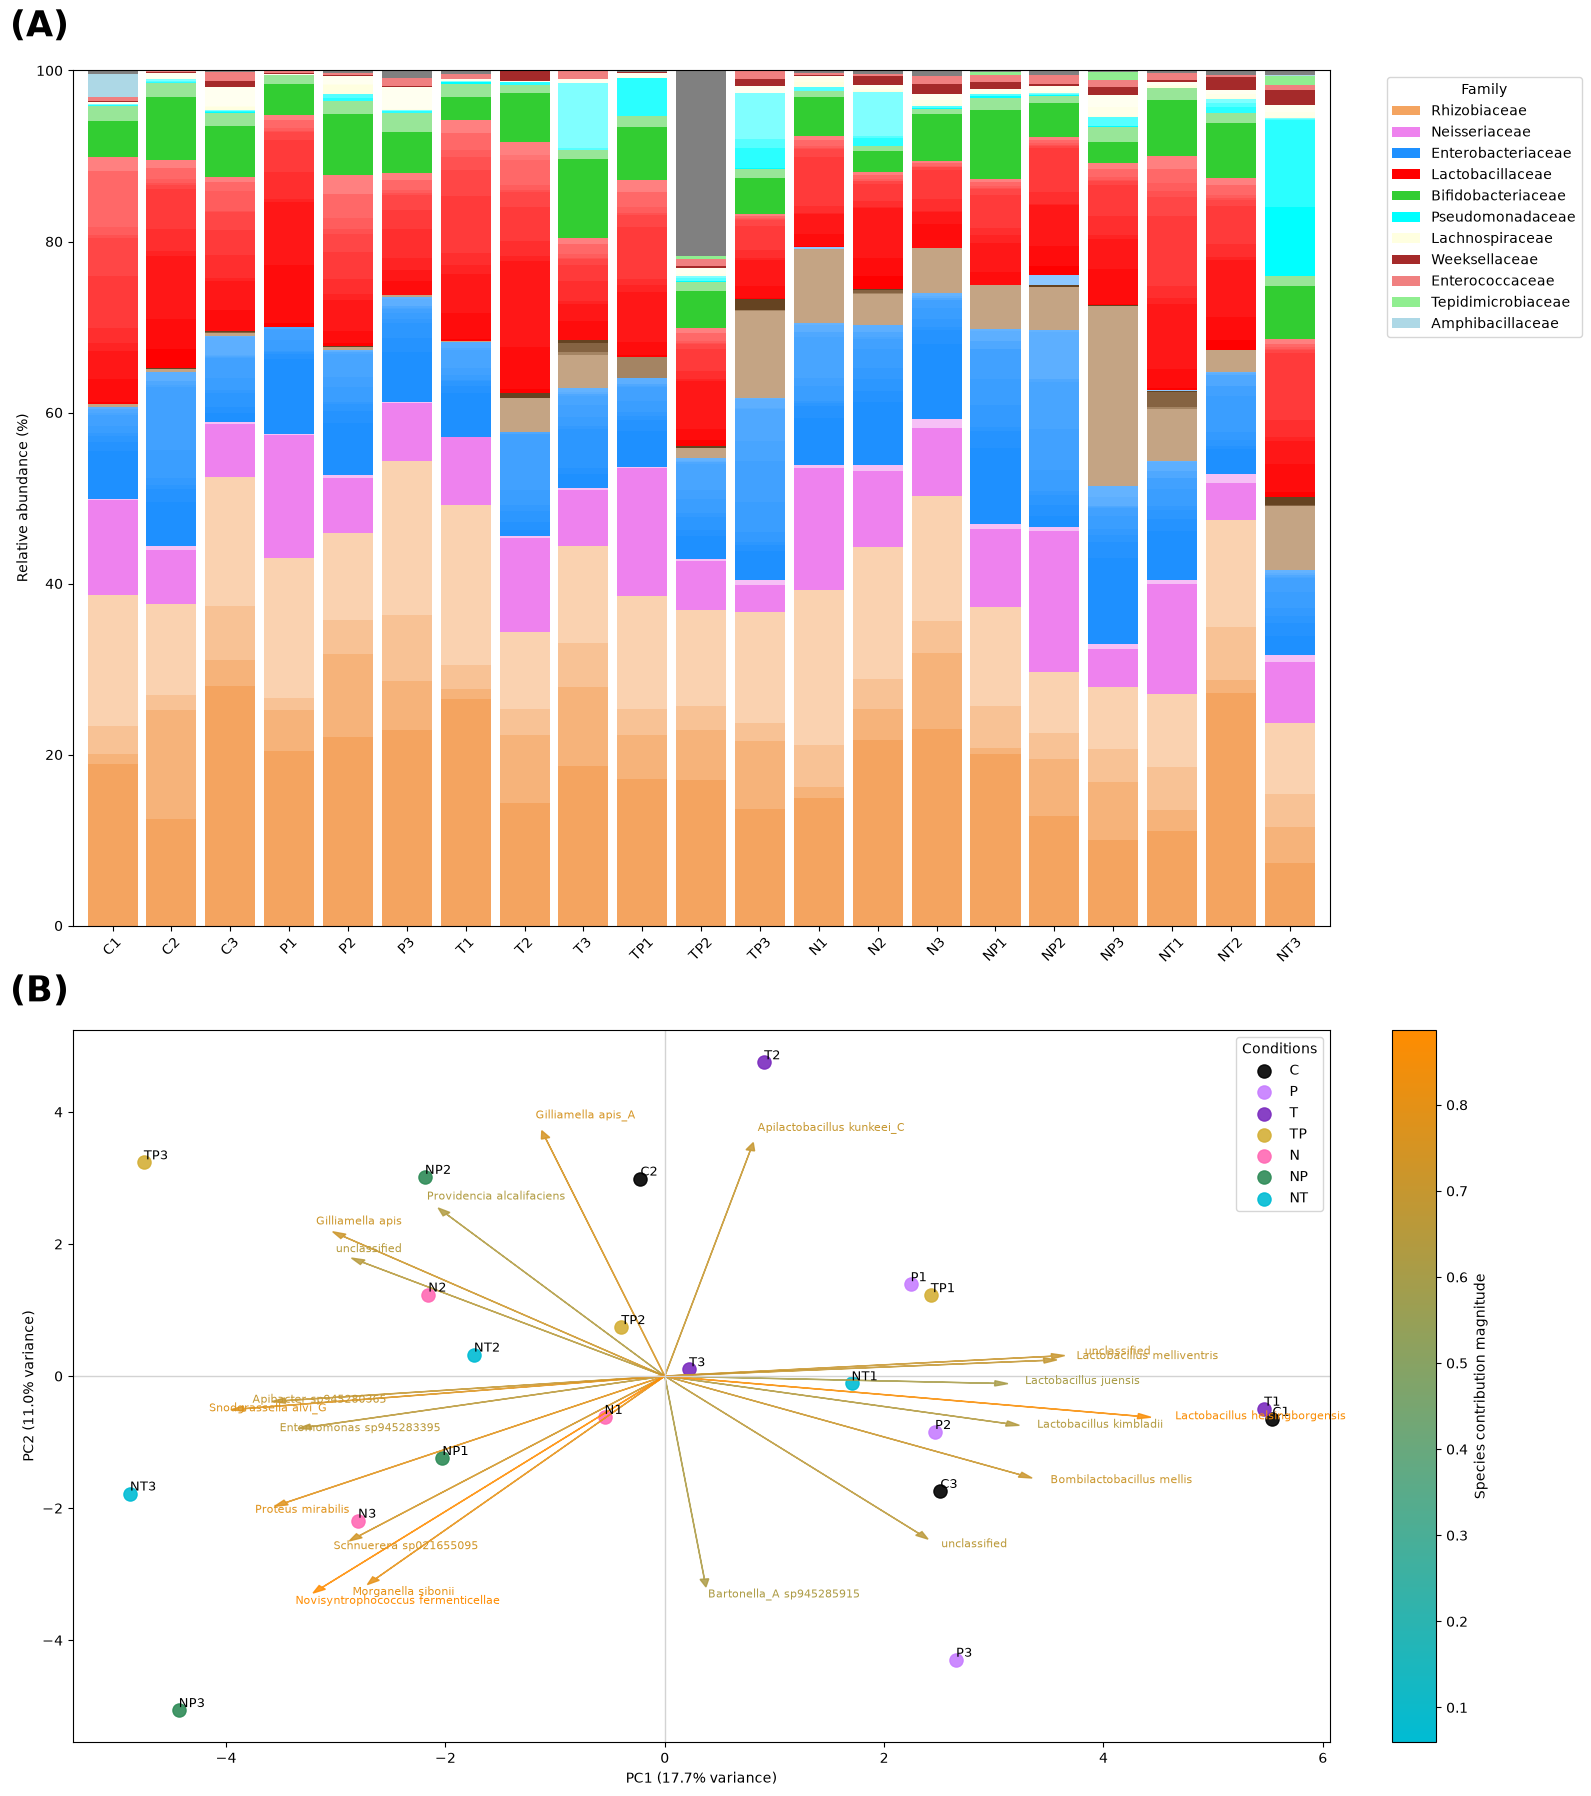

,PC1,PC2,Category
C1,5.540138,-0.647404,C
C2,-0.221877,2.991196,C
C3,2.512343,-1.740667,C
P1,2.241286,1.391336,P
P2,2.463905,-0.845904,P
P3,2.655445,-4.295899,P
T1,5.464940,-0.493513,T
T2,0.906287,4.752169,T
T3,0.221643,0.103212,T
TP1,2.425511,1.225605,TP


In [28]:
family_colors = {
    "Rhizobiaceae": "sandybrown",  # Bartonellaceae
    "Neisseriaceae": "violet",
    "Enterobacteriaceae": "dodgerblue",  # Orbaceae
    "Lactobacillaceae": "red",
    "Leuconostocaceae": "orange",
    "Bifidobacteriaceae": "limegreen",
    # not in the original paper
    "Pseudomonadaceae": "cyan",
    "Lachnospiraceae": "lightyellow",
    "Weeksellaceae": "brown",
    "Enterococcaceae": "lightcoral",
    "Tepidimicrobiaceae": "lightgreen",
    "Amphibacillaceae": "lightblue",
}

def make_family_shades(base_color, n):
    if n <= 1:
        return [mcolors.to_hex(base_color)]
    base_rgb = np.array(mcolors.to_rgb(base_color))
    white = np.array([1.0, 1.0, 1.0])
    factors = np.linspace(0.0, 0.5, n)
    return [mcolors.to_hex(base_rgb * (1 - f) + white * f) for f in factors]

def make_color_gradient(start_color, end_color, n):
    if n <= 1:
        return [mcolors.to_hex(start_color)]
    start_rgb = np.array(mcolors.to_rgb(start_color))
    end_rgb = np.array(mcolors.to_rgb(end_color))
    factors = np.linspace(0.0, 1.0, n)
    return [mcolors.to_hex(start_rgb * (1 - f) + end_rgb * f) for f in factors]

family_order = list(family_colors.keys())
family_rank = {family: rank for rank, family in enumerate(family_order)}

# Reorder species rows so stacked bars follow the requested family order
index_df = mq_relative_abund_df.index.to_frame(index=False)
index_df["sort_rank"] = index_df["Family"].map(family_rank).fillna(len(family_order)).astype(int)
index_df = index_df.sort_values(["sort_rank", "Family", "Genus", "Species"], kind="stable")
ordered_index = pd.MultiIndex.from_frame(index_df[["Family", "Genus", "Species"]])
species_abund_df_ordered = mq_relative_abund_df.loc[ordered_index]

# Default colors: same family hue, different shade within family
default_color_map = {}
for family_name, group in index_df.groupby("Family", sort=False):
    base_color = family_colors.get(family_name, "gray")
    shades = make_family_shades(base_color, len(group))
    for (_, row), shade in zip(group.iterrows(), shades):
        default_color_map[(row["Family"], row["Genus"], row["Species"])] = shade

# Special overrides requested by user
providencia_count = index_df["Genus"].astype(str).str.lower().str.startswith("providencia").sum()
providencia_shades = iter(make_color_gradient("#c4a484", "#654321", providencia_count))

species_colors = []
for _, row in index_df.iterrows():
    family_name = row["Family"]
    genus_name = str(row["Genus"]).strip().lower()
    species_name = str(row["Species"]).strip().lower()
    key = (row["Family"], row["Genus"], row["Species"])
    if genus_name.startswith("arsenophonus") and species_name == "apicola":
        color = "black"
    elif genus_name.startswith("proteus"):
        color = "#c4a484"  # light brown
    elif genus_name.startswith("providencia"):
        color = next(providencia_shades)
    else:
        color = default_color_map.get(key, family_colors.get(family_name, "gray"))
    species_colors.append(color)

sample_matrix = mq_relative_abund_df.select_dtypes(include=[np.number]).T
scaled_sample_matrix = StandardScaler().fit_transform(sample_matrix)
pca = PCA(n_components=2)
sample_scores = pca.fit_transform(scaled_sample_matrix)
species_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

sample_scores_df = pd.DataFrame(sample_scores, index=sample_matrix.index, columns=["PC1", "PC2"])
sample_scores_df["Category"] = (
    sample_scores_df.index.to_series()
    .str.extract(r"^(NT|NP|TP|C|T|P|N)", expand=False)
    .fillna("Other")
)

category_palette = {
    "C": "#000000",
    "T": "#7b2cbf",
    "P": "#c77dff",
    "N": "#ff69b4",
    "NT": "#00bcd4",
    "NP": "#2e8b57",
    "TP": "#d4af37",
    "Other": "#6c757d",
}

species_contribution = np.linalg.norm(species_loadings, axis=1)
contribution_norm = plt.Normalize(species_contribution.min(), species_contribution.max())
arrow_cmap = LinearSegmentedColormap.from_list("cyan_orange", ["#00bcd4", "#ff8c00"])
arrow_colors = arrow_cmap(contribution_norm(species_contribution))

top_species_idx = np.argsort(species_contribution)[-20:]
score_limit = np.abs(sample_scores_df[["PC1", "PC2"]].to_numpy()).max()
loading_limit = np.abs(species_loadings[top_species_idx]).max()
arrow_scale = 1.0 if loading_limit == 0 else (score_limit / loading_limit) * 0.8

fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(16, 18), gridspec_kw={"height_ratios": [1.2, 1]})

# (A) Relative abundance stacked bars
species_abund_df_ordered.T.plot(
    kind="bar",
    stacked=True,
    ax=ax_a,
    color=species_colors,
    width=0.85,
    legend=False,
)
ax_a.set_ylabel("Relative abundance (%)")
ax_a.set_ylim(0, 100)
ax_a.tick_params(axis="x", rotation=45)
present_families = [family for family in family_order if family in set(index_df["Family"])]
legend_handles = [
    Patch(facecolor=family_colors.get(family, "gray"), label=family)
    for family in present_families
]
right_margin_x = 1.05
ax_a.legend(handles=legend_handles, title="Family", bbox_to_anchor=(right_margin_x-0.01, 1), loc="upper left")
ax_a.text(-0.05, 1.04, "(A)", transform=ax_a.transAxes, fontsize=25, fontweight="bold")

# (B) PCA biplot
for category, frame in sample_scores_df.groupby("Category", sort=False):
    ax_b.scatter(
        frame["PC1"],
        frame["PC2"],
        s=90,
        color=category_palette.get(category, category_palette["Other"]),
        label=category,
        alpha=0.9,
    )
    for sample_name, row in frame.iterrows():
        ax_b.text(row["PC1"], row["PC2"], sample_name, fontsize=9, ha="left", va="bottom")

for idx in top_species_idx:
    species_name = mq_relative_abund_df.index[idx][2]
    x_loading = species_loadings[idx, 0] * arrow_scale
    y_loading = species_loadings[idx, 1] * arrow_scale
    ax_b.arrow(
        0,
        0,
        x_loading,
        y_loading,
        color=arrow_colors[idx],
        alpha=0.85,
        width=0.002,
        head_width=0.08,
        length_includes_head=True,
    )
    ax_b.text(x_loading * 1.05, y_loading * 1.05, species_name, color=arrow_colors[idx], fontsize=8)

explained_variance = pca.explained_variance_ratio_ * 100
ax_b.axhline(0, color="lightgray", linewidth=1)
ax_b.axvline(0, color="lightgray", linewidth=1)
ax_b.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)")
ax_b.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)")
ax_b.legend(title="Conditions")
ax_b.text(-0.05, 1.04, "(B)", transform=ax_b.transAxes, fontsize=25, fontweight="bold")

sm = plt.cm.ScalarMappable(cmap=arrow_cmap, norm=contribution_norm)
sm.set_array([])
cax_b = ax_b.inset_axes([right_margin_x, 0.0, 0.035, 1.0])
fig.colorbar(sm, cax=cax_b, label="Species contribution magnitude")

plt.tight_layout()
png_fp = result_dp / "mq_combined_relative_abundance_pca.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
print(f"Saved combined figure to: {png_fp}")
plt.show()

sample_scores_df

In [29]:
sample_scores_df

,PC1,PC2,Category
C1,5.540138,-0.647404,C
C2,-0.221877,2.991196,C
C3,2.512343,-1.740667,C
P1,2.241286,1.391336,P
P2,2.463905,-0.845904,P
P3,2.655445,-4.295899,P
T1,5.464940,-0.493513,T
T2,0.906287,4.752169,T
T3,0.221643,0.103212,T
TP1,2.425511,1.225605,TP


### Functions

In [30]:
print_stats(get_bakta_annot_df(mq_df).describe())

CDSs: 2165.53 ± 980.86, Median: 1951.00, IQR: 1427.50-2712.00, Range: 306.00-5032.00
CRISPR arrays: 0.95 ± 1.61, Median: 0.00, IQR: 0.00-2.00, Range: 0.00-9.00
gaps: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
hypotheticals: 287.42 ± 212.88, Median: 209.00, IQR: 124.50-369.50, Range: 44.00-808.00
ncRNA regions: 18.16 ± 12.96, Median: 15.00, IQR: 9.00-22.00, Range: 2.00-57.00
ncRNAs: 13.02 ± 16.44, Median: 6.00, IQR: 4.00-17.50, Range: 1.00-73.00
oriCs: 0.47 ± 0.63, Median: 0.00, IQR: 0.00-1.00, Range: 0.00-2.00
oriTs: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
oriVs: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
pseudogenes: 13.20 ± 11.15, Median: 9.00, IQR: 6.00-16.00, Range: 1.00-46.00
rRNAs: 1.42 ± 1.60, Median: 1.00, IQR: 0.00-2.00, Range: 0.00-7.00
sORFs: 1.05 ± 2.70, Median: 0.00, IQR: 0.00-0.50, Range: 0.00-15.00
signal peptides: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
tRNAs: 34.24 ± 15.93, Median: 30.00, IQR: 24

In [31]:
mq_kegg_module_df = get_kegg_path_df(mq_df)

Before removing rows and columns with only zeros:
Clusters: 55
KEGG modules: 319

After removing rows and columns with only zeros:
Clusters: 55
KEGG modules: 303

KEGG modules: 161.55 ± 38.31, Median: 163.00, IQR: 132.50-191.50, Range: 81.00-233.00


In [32]:
# Count how many KEGG pathways reach a given completeness threshold for each MAG
thresholds = [50, 75, 100]
kegg_path_counts_df = pd.DataFrame(index=mq_kegg_module_df.index)

for threshold in thresholds:
    kegg_path_counts_df[f"Modules with completeness >= {threshold}%"] = (mq_kegg_module_df >= threshold).sum(axis=1)

kegg_path_counts_df = kegg_path_counts_df.sort_values(by="Modules with completeness >= 50%", ascending=False)
kegg_path_counts_df.describe()

,Modules with completeness >= 50%,Modules with completeness >= 75%,Modules with completeness >= 100%
count,55.000000,55.000000,55.000000
mean,89.200000,52.436364,34.690909
std,38.412189,27.536349,22.402772
min,22.000000,6.000000,4.000000
25%,58.500000,32.500000,18.500000
50%,87.000000,49.000000,31.000000
75%,118.500000,72.500000,47.000000
max,174.000000,122.000000,101.000000


In [33]:
# Count in how many MAGs a KEGG pathway reaches a given completeness threshold
kegg_pathway_mag_counts_df = pd.DataFrame(index=mq_kegg_module_df.columns)

for threshold in thresholds:
    kegg_pathway_mag_counts_df[f"MAGs with completeness >= {threshold}%"] = (mq_kegg_module_df >= threshold).sum(axis=0)

kegg_pathway_mag_counts_df = kegg_pathway_mag_counts_df.sort_values(by="MAGs with completeness >= 50%", ascending=False)
kegg_pathway_mag_counts_df

,MAGs with completeness >= 50%,MAGs with completeness >= 75%,MAGs with completeness >= 100%
"Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate",55,44,18
"Glycolysis, core module involving three-carbon compounds",54,48,31
"Guanine ribonucleotide biosynthesis, IMP => GDP,GTP",54,46,25
"Gluconeogenesis, oxaloacetate => fructose-6P",53,37,19
Pentose phosphate pathway (Pentose phosphate cycle),53,39,14
...,...,...,...
"Glycosaminoglycan biosynthesis, linkage tetrasaccharide",0,0,0
"Heme biosynthesis, archaea, siroheme => heme",0,0,0
Heparan sulfate degradation,0,0,0
Hydroxypropionate-hydroxybutylate cycle,0,0,0


In [34]:
print(f"Number of pathways with completeness < 50% in all MAG: {((mq_kegg_module_df < 50).all(axis=0)).sum()}")
print(f"Number of pathways with completeness < 75% in all MAG: {((mq_kegg_module_df < 75).all(axis=0)).sum()}")
print(f"Number of pathways with completeness >= 50 % in all MAG: {((mq_kegg_module_df >= 50).all(axis=0)).sum()}")
print(f"Number of pathways with completeness >= 75 % in all MAG: {((mq_kegg_module_df >= 75).all(axis=0)).sum()}")

Number of pathways with completeness < 50% in all MAG: 88
Number of pathways with completeness < 75% in all MAG: 142
Number of pathways with completeness >= 50 % in all MAG: 1
Number of pathways with completeness >= 75 % in all MAG: 0


In [35]:
kegg_pathway_mag_counts_df.index[kegg_pathway_mag_counts_df.iloc[:, 0].eq(32)].tolist()

['Lipoic acid biosynthesis, plants and bacteria, octanoyl-ACP => dihydrolipoyl-E2/H',
 'Semi-phosphorylative Entner-Doudoroff pathway, gluconate => glycerate-3P',
 'Siroheme biosynthesis, glutamyl-tRNA => siroheme',
 'Heme biosynthesis, plants and bacteria, glutamate => heme']

## LQ: Low-quality species-level clusters (contamination < 10% and completeness < 50%)

In [36]:
lq_df = reps_df.query("Contamination < 10 and Completeness < 50")
compute_print_stats(lq_df)
print(f"Total number: {len(lq_df)} ({len(lq_df) / len(reps_df) * 100:.2f}%)")

Total number: 683.0
Cluster members: 1.33 ± 1.28, Median: 1.00, IQR: 1.00-1.00, Range: 1.00-15.00
Contamination: 1.02 ± 1.78, Median: 0.28, IQR: 0.05-0.95, Range: 0.00-9.97
Completeness: 12.57 ± 7.99, Median: 10.00, IQR: 7.45-14.30, Range: 2.20-44.90
Total length: 0.42 ± 0.29, Median: 0.32, IQR: 0.23-0.50, Range: 0.05-2.85
Total number: 683 (92.55%)


## Non classified

In [37]:
nc_df = reps_df.query("Contamination >= 10")
print(f"Total number: {len(nc_df)} ({len(nc_df) / len(reps_df) * 100:.2f}%)")

Total number: 0 (0.00%)


## Relative abundance with all MAGs

In [38]:
abund_df = get_relative_abund_taxo_levels(reps_df, coverage_df)

Unmapped reads: 3.92 ± 1.48, Median: 3.55, IQR: 2.65-4.53, Range: 2.27-7.33
Mapped reads: 96.08 ± 1.48, Median: 96.45, IQR: 95.47-97.35, Range: 92.67-97.73

Level: Family


,count,mean,std,min,25%,50%,75%,max
Family,,,,,,,,
Bartonella,21.0,39.511684,2.877863,32.814621,37.966871,39.753643,41.558307,44.153293
Rhizobiaceae,21.0,24.205092,2.026092,19.747549,23.040722,24.629234,25.469066,26.860894
unclassified,21.0,11.205694,1.486451,9.528785,10.141774,10.885174,11.571179,15.712553
Bartonellaceae,21.0,8.947521,1.091989,6.865446,8.123995,9.099437,9.706253,10.999102
Orbaceae,21.0,3.292080,1.208452,1.479351,2.454249,2.909518,4.068311,5.725454
Enterobacteriaceae,21.0,2.715560,1.198971,1.099203,1.860773,2.445306,3.480057,5.249123
Lactobacillaceae,21.0,2.701158,1.059005,1.123424,1.909207,2.766435,3.162282,4.999163
Bifidobacteriaceae,21.0,2.570643,0.690450,1.026825,2.226049,2.581659,3.098180,3.620755
Neisseriaceae,21.0,1.208291,0.571458,0.404359,0.798859,1.051230,1.691982,2.598630



Level: Genus


,count,mean,std,min,25%,50%,75%,max
Genus,,,,,,,,
environmental samples,21.0,38.322282,2.866487,31.675623,37.090824,38.414252,40.684509,42.748708
Bartonella_A,21.0,24.205092,2.026092,19.747549,23.040722,24.629234,25.469066,26.860894
unclassified,21.0,11.205694,1.486451,9.528785,10.141774,10.885174,11.571179,15.712553
Ditibartonella,21.0,8.947521,1.091989,6.865446,8.123995,9.099437,9.706253,10.999102
Gilliamella,21.0,5.286619,2.053584,2.314478,4.046922,4.604412,6.879856,9.342555
Lactobacillus,21.0,1.796367,0.866677,0.700336,1.122477,1.618610,2.412139,3.817167
Bifidobacterium,21.0,1.479026,0.397818,0.516125,1.275841,1.475646,1.706683,2.171064
unclassified Bartonella,21.0,1.471592,0.155593,1.251280,1.342228,1.462027,1.531214,1.770415
Snodgrassella,21.0,1.208291,0.571458,0.404359,0.798859,1.051230,1.691982,2.598630



Level: Species


,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
uncultured Bartonella sp.,21.0,38.040093,2.869257,31.496102,36.473639,38.250684,40.211770,42.655448
unclassified,21.0,34.146944,0.952191,32.392552,33.453208,34.301506,34.703710,35.612647
Ditibartonella apis,21.0,7.313215,1.018291,5.454496,6.582471,7.453302,7.850415,9.391300
Gilliamella apicola,21.0,3.367098,1.214059,1.519258,2.509602,3.018066,4.190838,5.861272
Bartonella_A apis,21.0,1.614020,0.380430,0.916821,1.420962,1.545840,1.858835,2.424263
...,...,...,...,...,...,...,...,...
Serratia sp. S0636,21.0,0.001868,0.006126,0.000000,0.000000,0.000000,0.000000,0.027794
Klebsiella grimontii,21.0,0.001817,0.006710,0.000000,0.000000,0.000000,0.000000,0.030600
Lactobacillus panisapium,21.0,0.001740,0.007975,0.000000,0.000000,0.000000,0.000000,0.036548


In [39]:
run_to_replicate = metadata_df.set_index("Run accession")["Replicate"].to_dict()
abund_df = abund_df.rename(
    columns={
        column: run_to_replicate[column]
        for column in abund_df.columns
        if column.startswith("SRR") and column in run_to_replicate
    }
)

abund_df =abund_df[[*sample_order]]
abund_df.head()

C1  \
Family           Genus                     Species                                                  
Amphibacillaceae Oceanobacillus            Oceanobacillus sp032085455                    0.000000   
                 Virgibacillus             Virgibacillus proomii_B                       0.128342   
Arsenophonus     unclassified Arsenophonus Arsenophonus endosymbiont of Apis mellifera   0.048853   
Bacillaceae      Cytobacillus              Cytobacillus horneckiae                       0.030728   
Bartonella       environmental samples     uncultured Bartonella sp.                    40.211770   

                                                                                               C2  \
Family           Genus                     Species                                                  
Amphibacillaceae Oceanobacillus            Oceanobacillus sp032085455                    0.000000   
                 Virgibacillus             Virgibacillus proomii_B                       0.000000   
Arsenophonus     unclassified Arsenophonus Arsenophonus endosymbiont of Apis mellifera   0.025895   
Bacillaceae      Cytobacillus              Cytobacillus horneckiae                       0.000000   
Bartonella       environmental samples     uncultured Bartonella sp.                    37.469499   

                                                                                               C3  \
Family           Genus                     Species                                                  
Amphibacillaceae Oceanobacillus            Oceanobacillus sp032085455                    0.020483   
                 Virgibacillus             Virgibacillus proomii_B                       0.001608   
Arsenophonus     unclassified Arsenophonus Arsenophonus endosymbiont of Apis mellifera   0.022644   
Bacillaceae      Cytobacillus              Cytobacillus horneckiae                       0.000000   
Bartonella       environmental samples     uncultured Bartonella sp.                    38.983450   

                                                                                               P1  \
Family           Genus                     Species                                                  
Amphibacillaceae Oceanobacillus            Oceanobacillus sp032085455                    0.000000   
                 Virgibacillus             Virgibacillus proomii_B                       0.000000   
Arsenophonus     unclassified Arsenophonus Arsenophonus endosymbiont of Apis mellifera   0.010786   
Bacillaceae      Cytobacillus              Cytobacillus horneckiae                       0.000000   
Bartonella       environmental samples     uncultured Bartonella sp.                    40.931539   

                                                                                               P2  \
Family           Genus                     Species                                                  
Amphibacillaceae Oceanobacillus            Oceanobacillus sp032085455                    0.005115   
                 Virgibacillus             Virgibacillus proomii_B                       0.000000   
Arsenophonus     unclassified Arsenophonus Arsenophonus endosymbiont of Apis mellifera   0.032952   
Bacillaceae      Cytobacillus              Cytobacillus horneckiae                       0.000000   
Bartonella       environmental samples     uncultured Bartonella sp.                    38.316501   

                                                                                               P3  \
Family           Genus                     Species                                                  
Amphibacillaceae Oceanobacillus            Oceanobacillus sp032085455                    0.000000   
                 Virgibacillus             Virgibacillus proomii_B                       0.000000   
Arsenophonus     unclassified Arsenophonus Arsenophonus endosymbiont of Apis mellifera   0.113526   
Bacillaceae      Cytobacillus              Cytobac

### Relative abundance of control data

In [40]:
control_species_abund_df = abund_df[["C1", "C2", "C3"]]
control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False)

,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Bartonella,environmental samples,uncultured Bartonella sp.,3.0,38.888240,1.373613,37.469499,38.226475,38.983450,39.597610,40.211770
Rhizobiaceae,Bartonella_A,unclassified,3.0,20.532713,1.818305,18.434047,19.980952,21.527856,21.582045,21.636235
unclassified,unclassified,unclassified,3.0,9.930875,0.512823,9.528785,9.642117,9.755448,10.131919,10.508390
Bartonellaceae,Ditibartonella,Ditibartonella apis,3.0,7.836172,1.562298,6.266800,7.058608,7.850415,8.620858,9.391300
Orbaceae,Gilliamella,Gilliamella apicola,3.0,3.153470,1.671649,1.946338,2.199473,2.452608,3.757036,5.061465
...,...,...,...,...,...,...,...,...,...,...
Enterobacteriaceae,Serratia,Serratia ureilytica,3.0,0.000641,0.001110,0.000000,0.000000,0.000000,0.000962,0.001923
Dysgonomonadaceae,Dysgonomonas,unclassified,3.0,0.000395,0.000684,0.000000,0.000000,0.000000,0.000592,0.001184
Lactobacillaceae,Lactobacillus,Lactobacillus panisapium,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [41]:
#control_species_abund_df.xs("Bartonella_A", level=1, axis=0, drop_level=False).sum(axis=0).describe()

### Relative abundance of all experimental conditions

In [42]:
control_species_abund_df = abund_df[["C1", "C2", "C3"]]
display(control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False))

infected_species_abund_df = abund_df[["N1", "N2", "N3"]]
display(infected_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False))

,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Bartonella,environmental samples,uncultured Bartonella sp.,3.0,38.888240,1.373613,37.469499,38.226475,38.983450,39.597610,40.211770
Rhizobiaceae,Bartonella_A,unclassified,3.0,20.532713,1.818305,18.434047,19.980952,21.527856,21.582045,21.636235
unclassified,unclassified,unclassified,3.0,9.930875,0.512823,9.528785,9.642117,9.755448,10.131919,10.508390
Bartonellaceae,Ditibartonella,Ditibartonella apis,3.0,7.836172,1.562298,6.266800,7.058608,7.850415,8.620858,9.391300
Orbaceae,Gilliamella,Gilliamella apicola,3.0,3.153470,1.671649,1.946338,2.199473,2.452608,3.757036,5.061465
...,...,...,...,...,...,...,...,...,...,...
Enterobacteriaceae,Serratia,Serratia ureilytica,3.0,0.000641,0.001110,0.000000,0.000000,0.000000,0.000962,0.001923
Dysgonomonadaceae,Dysgonomonas,unclassified,3.0,0.000395,0.000684,0.000000,0.000000,0.000000,0.000592,0.001184
Lactobacillaceae,Lactobacillus,Lactobacillus panisapium,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Bartonella,environmental samples,uncultured Bartonella sp.,3.0,39.992246,2.411698,37.955802,38.660645,39.365489,41.010468,42.655448
Rhizobiaceae,Bartonella_A,unclassified,3.0,21.086688,0.103398,21.012881,21.027599,21.042317,21.123591,21.204866
unclassified,unclassified,unclassified,3.0,10.926172,0.081019,10.873845,10.879510,10.885174,10.952335,11.019496
Bartonellaceae,Ditibartonella,Ditibartonella apis,3.0,7.788038,0.428833,7.480432,7.543109,7.605787,7.941841,8.277894
Orbaceae,Gilliamella,Gilliamella apicola,3.0,2.972971,0.260353,2.783920,2.824493,2.865065,3.067497,3.269928
...,...,...,...,...,...,...,...,...,...,...
Tepidimicrobiaceae,Schnuerera,Schnuerera sp021655095,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Clostridium,unclassified Clostridium,Clostridium sp. Cult1,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Enterobacteriaceae,Klebsiella,Klebsiella grimontii,3.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [43]:
for sample in abund_df.columns:
    print(f"Sample: {sample}")
    top_species = abund_df[sample].nlargest(5)
    display(top_species)

Sample: C1


Family          Genus                  Species                  
Bartonella      environmental samples  uncultured Bartonella sp.    40.211770
Rhizobiaceae    Bartonella_A           unclassified                 21.527856
unclassified    unclassified           unclassified                  9.755448
Bartonellaceae  Ditibartonella         Ditibartonella apis           7.850415
Orbaceae        Gilliamella            Gilliamella apicola           1.946338
Name: C1, dtype: float64

Sample: C2


Family          Genus                  Species                  
Bartonella      environmental samples  uncultured Bartonella sp.    37.469499
Rhizobiaceae    Bartonella_A           unclassified                 18.434047
unclassified    unclassified           unclassified                 10.508390
Bartonellaceae  Ditibartonella         Ditibartonella apis           6.266800
Orbaceae        Gilliamella            Gilliamella apicola           5.061465
Name: C2, dtype: float64

Sample: C3


...

Family          Genus                  Species                  
Bartonella      environmental samples  uncultured Bartonella sp.    36.407806
Rhizobiaceae    Bartonella_A           unclassified                 18.561839
unclassified    unclassified           unclassified                 11.922573
Bartonellaceae  Ditibartonella         Ditibartonella apis           6.087224
Orbaceae        Gilliamella            Gilliamella apicola           3.396583
Name: NT1, dtype: float64

Sample: NT2


Family          Genus                  Species                  
Bartonella      environmental samples  uncultured Bartonella sp.    36.824173
Rhizobiaceae    Bartonella_A           unclassified                 21.371916
unclassified    unclassified           unclassified                 11.571179
Bartonellaceae  Ditibartonella         Ditibartonella apis           8.578274
Orbaceae        Gilliamella            Gilliamella apicola           2.900594
Name: NT2, dtype: float64

Sample: NT3


Family          Genus                  Species                  
Bartonella      environmental samples  uncultured Bartonella sp.    36.473639
Rhizobiaceae    Bartonella_A           unclassified                 16.758554
unclassified    unclassified           unclassified                 13.202216
Bartonellaceae  Ditibartonella         Ditibartonella apis           5.454496
Orbaceae        Gilliamella            Gilliamella apicola           4.331945
Name: NT3, dtype: float64

In [44]:
arsenophonus_abund_df = abund_df.xs("Arsenophonus apicola", level=2, axis=0, drop_level=False).T
print(f"Abundance for Arsenophonus apicola in TP2: {arsenophonus_abund_df.loc['TP2'].values[0]}")
print("Abundance for Arsenophonus apicola without TP2 sample: ")
arsenophonus_abund_df.drop(["TP2"]).describe().T

Abundance for Arsenophonus apicola in TP2: 1.2172405142240394
Abundance for Arsenophonus apicola without TP2 sample: 


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Enterobacteriaceae_A,Arsenophonus,Arsenophonus apicola,20.0,0.005324,0.007477,0.0,0.0,0.003596,0.006511,0.032682
Morganellaceae,Arsenophonus,Arsenophonus apicola,20.0,0.004694,0.004660,0.0,0.0,0.003927,0.006749,0.017814


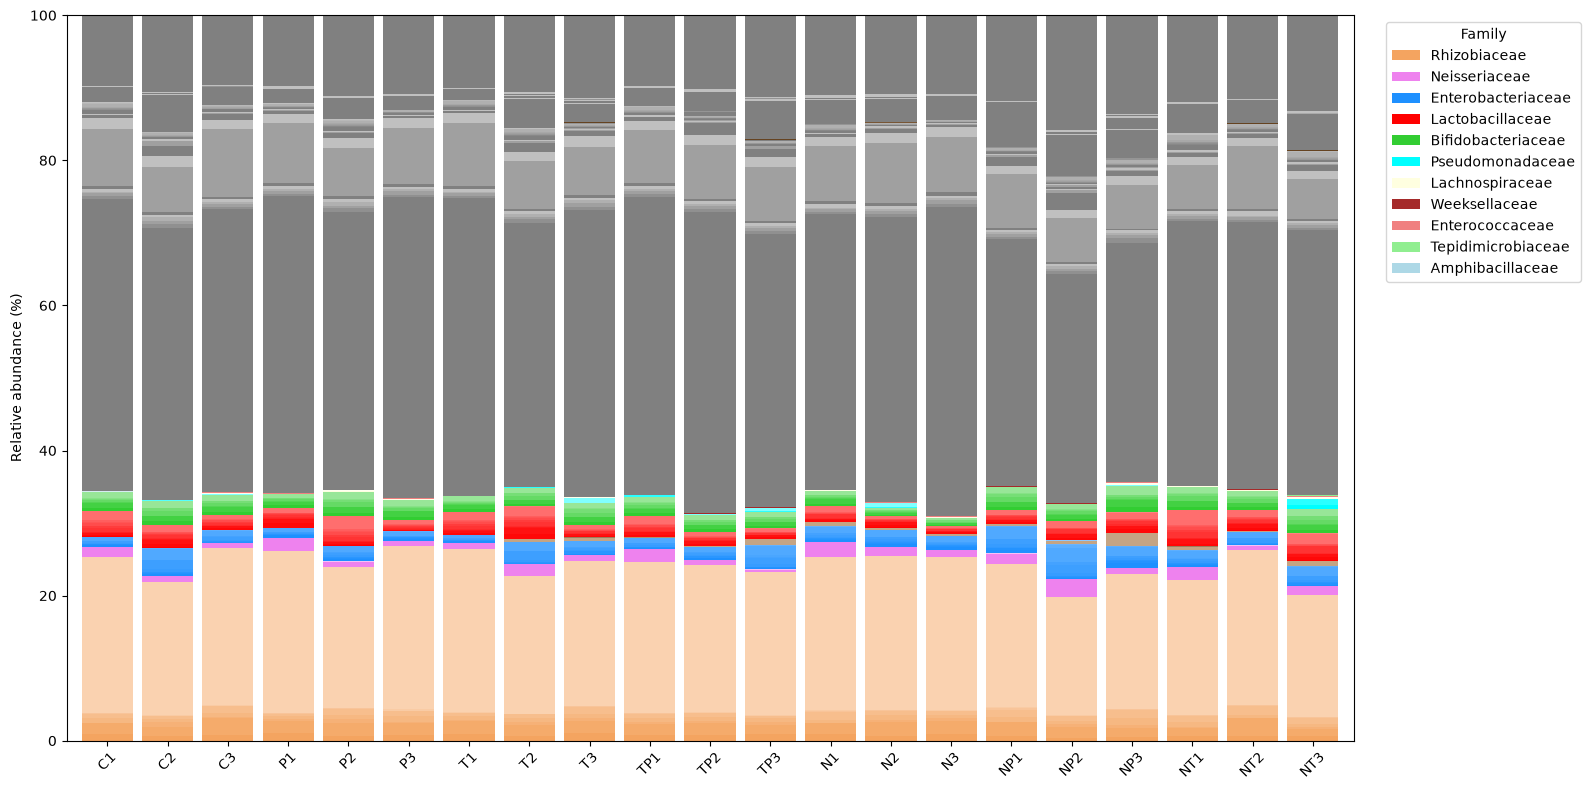

In [45]:
# Reorder species rows so stacked bars follow the requested family order
index_df = abund_df.index.to_frame(index=False)
index_df["sort_rank"] = index_df["Family"].map(family_rank).fillna(len(family_order)).astype(int)
index_df = index_df.sort_values(["sort_rank", "Family", "Genus", "Species"], kind="stable")
ordered_index = pd.MultiIndex.from_frame(index_df[["Family", "Genus", "Species"]])
species_abund_df_ordered = abund_df.loc[ordered_index]

# Default colors: same family hue, different shade within family
default_color_map = {}
for family_name, group in index_df.groupby("Family", sort=False):
    base_color = family_colors.get(family_name, "gray")
    shades = make_family_shades(base_color, len(group))
    for (_, row), shade in zip(group.iterrows(), shades):
        default_color_map[(row["Family"], row["Genus"], row["Species"])] = shade

# Special overrides requested by user
providencia_count = index_df["Genus"].astype(str).str.lower().str.startswith("providencia").sum()
providencia_shades = iter(make_color_gradient("#c4a484", "#654321", providencia_count))

species_colors = []
for _, row in index_df.iterrows():
    family_name = row["Family"]
    genus_name = str(row["Genus"]).strip().lower()
    species_name = str(row["Species"]).strip().lower()
    key = (row["Family"], row["Genus"], row["Species"])
    if genus_name.startswith("arsenophonus") and species_name == "apicola":
        color = "black"
    elif genus_name.startswith("proteus"):
        color = "#c4a484"  # light brown
    elif genus_name.startswith("providencia"):
        color = next(providencia_shades)
    else:
        color = default_color_map.get(key, family_colors.get(family_name, "gray"))
    species_colors.append(color)

fig, ax = plt.subplots(figsize=(16, 8))
species_abund_df_ordered.T.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=species_colors,
    width=0.85,
    legend=False,
 )

ax.set_ylabel("Relative abundance (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=45)

present_families = [family for family in family_order if family in set(index_df["Family"])]
legend_handles = [
    Patch(facecolor=family_colors.get(family, "gray"), label=family)
    for family in present_families
]
ax.legend(handles=legend_handles, title="Family", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
png_fp = result_dp / "taxonomy_relative_abundance_biplot.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
plt.show()

### PCA

Saved PCA biplot to: ../results/use-cases/bee-gut/taxonomy_pca_biplot.png


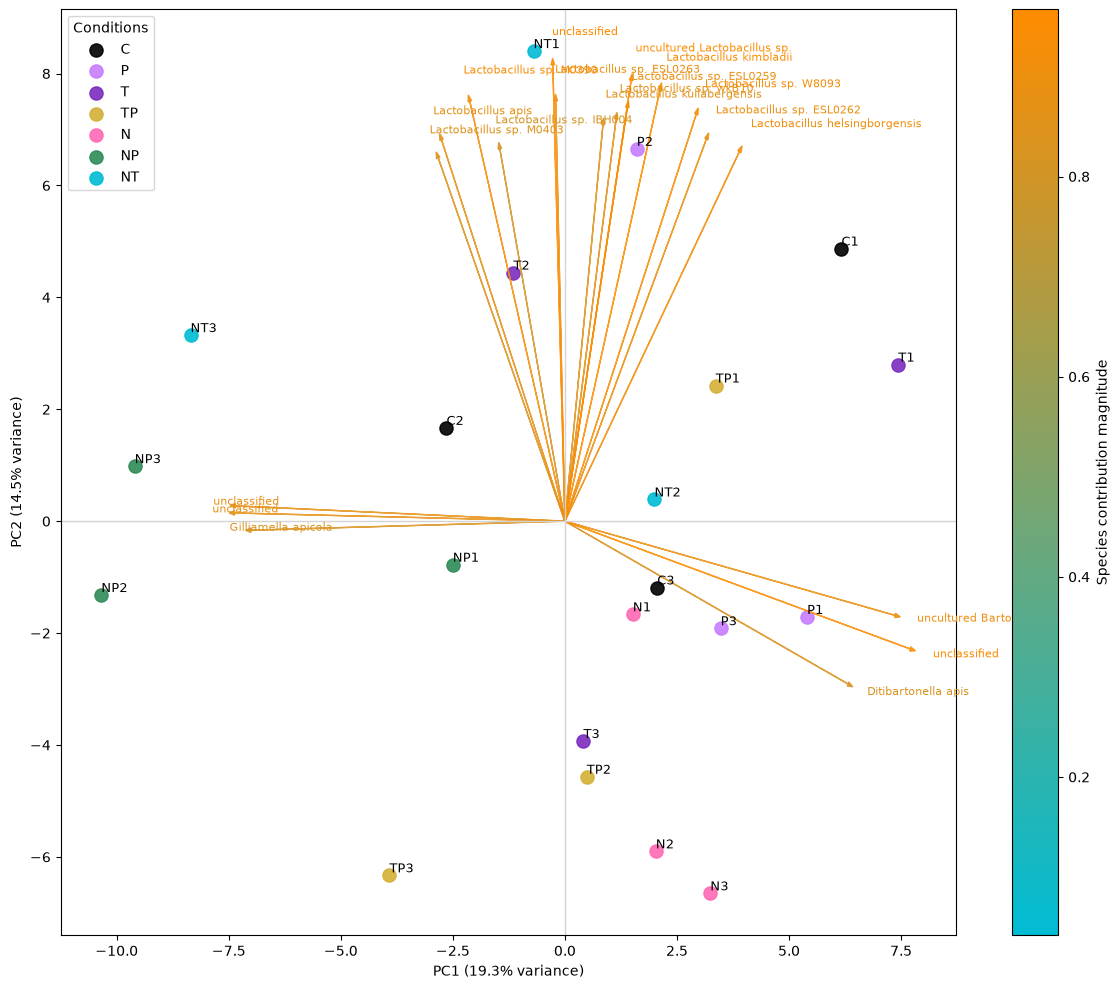

,PC1,PC2,Category
C1,6.169709,4.871493,C
C2,-2.641947,1.667212,C
C3,2.059711,-1.185997,C
P1,5.403140,-1.711011,P
P2,1.603287,6.654358,P
P3,3.474766,-1.914388,P
T1,7.438366,2.798359,T
T2,-1.149320,4.442651,T
T3,0.413644,-3.929967,T
TP1,3.363880,2.424221,TP


In [46]:
sample_matrix = abund_df.select_dtypes(include=[np.number]).T

scaled_sample_matrix = StandardScaler().fit_transform(sample_matrix)
pca = PCA(n_components=2)
sample_scores = pca.fit_transform(scaled_sample_matrix)
species_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

sample_scores_df = pd.DataFrame(sample_scores, index=sample_matrix.index, columns=["PC1", "PC2"])
sample_scores_df["Category"] = (
    sample_scores_df.index.to_series()
    .str.extract(r"^(NT|NP|TP|C|T|P|N)", expand=False)
    .fillna("Other")
)

species_contribution = np.linalg.norm(species_loadings, axis=1)
contribution_norm = plt.Normalize(species_contribution.min(), species_contribution.max())
arrow_cmap = LinearSegmentedColormap.from_list("cyan_orange", ["#00bcd4", "#ff8c00"])
arrow_colors = arrow_cmap(contribution_norm(species_contribution))

top_species_idx = np.argsort(species_contribution)[-20:]
score_limit = np.abs(sample_scores_df[["PC1", "PC2"]].to_numpy()).max()
loading_limit = np.abs(species_loadings[top_species_idx]).max()
arrow_scale = 1.0 if loading_limit == 0 else (score_limit / loading_limit) * 0.8

fig, ax = plt.subplots(figsize=(12, 10))

for category, frame in sample_scores_df.groupby("Category", sort=False):
    ax.scatter(
        frame["PC1"],
        frame["PC2"],
        s=90,
        color=category_palette.get(category, category_palette["Other"]),
        label=category,
        alpha=0.9,
    )
    for sample_name, row in frame.iterrows():
        ax.text(row["PC1"], row["PC2"], sample_name, fontsize=9, ha="left", va="bottom")

for idx in top_species_idx:
    species_name = abund_df.index[idx][2]
    x_loading = species_loadings[idx, 0] * arrow_scale
    y_loading = species_loadings[idx, 1] * arrow_scale
    ax.arrow(
        0,
        0,
        x_loading,
        y_loading,
        color=arrow_colors[idx],
        alpha=0.85,
        width=0.002,
        head_width=0.08,
        length_includes_head=True,
    )
    ax.text(x_loading * 1.05, y_loading * 1.05, species_name, color=arrow_colors[idx], fontsize=8)

explained_variance = pca.explained_variance_ratio_ * 100
ax.axhline(0, color="lightgray", linewidth=1)
ax.axvline(0, color="lightgray", linewidth=1)
ax.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)")
ax.legend(title="Conditions")

sm = plt.cm.ScalarMappable(cmap=arrow_cmap, norm=contribution_norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Species contribution magnitude")

plt.tight_layout()
png_fp = result_dp / "taxonomy_pca_biplot.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
print(f"Saved PCA biplot to: {png_fp}")
plt.show()

sample_scores_df

## Comparison of MAGs taxonomy with original study

In [47]:
count = df_expert[
    df_expert["Origin"].astype(str).str.contains("Built MAG", na=False)
    & (df_expert["Differences between NCBI and GTDB taxonomies"] == "Yes")].shape[0]
print(f"Number of MAGs with differences between NCBI and GTDB taxonomies: {count}")

Number of MAGs with differences between NCBI and GTDB taxonomies: 20


### Statistics for MAGs origin

In [48]:
origin_df = df_expert["Origin"].value_counts(dropna=False).to_frame("count")
origin_df

,count
Origin,
"Built MAG, Species listed in the paper",19
Built MAG,19
Species listed in the paper,10


### Species identified by MAGs

#### Concordant = corresponding to species listed in the paper 

In [49]:
concordant_mags = df_expert.query("Origin == 'Built MAG, Species listed in the paper' and Species.notna()")
concordant_mags

,Name,Domain,Phylum,Class,Order,Family,Genus,Species,Species found in the paper,Differences between NCBI and GTDB taxonomies,...,Origin,Expected in such environment?,Microbiota type,Comment,Expert name,Species-level MAG count,Completeness,Contamination,Genome Size,GC Content
0,SRR24759604_bin_107333,Bacteria,Actinomycetota,Actinomycetes,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium indicum,Bifidobacterium coryneforme,Yes,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper (Figure ?),NaN,8.0,96.81,2.42,1882718.0,0.61
2,SRR24759612_bin_52183,Bacteria,Bacillota,Bacilli,Bacillales_D,Amphibacillaceae,Virgibacillus,Virgibacillus proomii_B,Virgibacillus proomii,Yes,...,"Built MAG, Species listed in the paper",Yes,Non-core,listed in the paper as Virgibacillus proomis (...,NaN,1.0,99.85,0.99,4560752.0,0.36
4,SRR24759605_bin_65734,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Apilactobacillus,Apilactobacillus apinorum,Apilactobacillus apinorum,No,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 2),NaN,4.0,75.77,1.20,1054200.0,0.34
5,SRR24759606_bin_54634,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Apilactobacillus,Apilactobacillus kunkeei_C,Apilactobacillus kunkeei,Yes,...,"Built MAG, Species listed in the paper",Yes,Non-core,NaN,NaN,15.0,98.66,1.47,1404564.0,0.37
6,SRR24759613_bin_56459,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Bombilactobacillus,Bombilactobacillus mellis,Bombilactobacillus mellis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,4.0,85.51,0.83,1473654.0,0.37
8,SRR24759613_bin_39911,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Fructobacillus,Fructobacillus fructosus,Fructobacillus fructosus,No,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 2),NaN,17.0,97.52,0.23,1276613.0,0.45
9,SRR24759604_bin_148146,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus apis,Lactobacillus apis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,1.0,75.44,2.08,1396370.0,0.37
10,SRR24759603_bin_355,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus helsingborgensis,Lactobacillus helsingborgensis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,6.0,83.57,2.45,1543830.0,0.37
11,SRR24759616_bin_28305,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus melliventris,Lactobacillus melliventris,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,3.0,77.35,3.09,1403520.0,0.36
16,SRR24759613_bin_105744,Bacteria,Bacillota_A,Clostridia,Lachnospirales,Lachnospiraceae,Novisyntrophococcus,Novisyntrophococcus liquoris,Blautia liquoris,Yes,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 4),NaN,9.0,98.77,0.13,3595826.0,0.42


In [50]:
concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,19.000000,19.000000,1.900000e+01
mean,89.672632,1.898421,2.436661e+06
std,10.374308,2.317871,1.258594e+06
min,75.030000,0.050000,1.054200e+06
25%,78.005000,0.220000,1.439109e+06
50%,95.790000,1.200000,2.035396e+06
75%,99.170000,2.435000,3.357385e+06
max,100.000000,9.790000,5.438933e+06


#### Non concordant = NOT corresponding to species listed in the paper

In [51]:
non_concordant_mags = df_expert.query("Origin == 'Built MAG' and Species.notna()")
non_concordant_mags

,Name,Domain,Phylum,Class,Order,Family,Genus,Species,Species found in the paper,Differences between NCBI and GTDB taxonomies,...,Origin,Expected in such environment?,Microbiota type,Comment,Expert name,Species-level MAG count,Completeness,Contamination,Genome Size,GC Content
3,SRR24759610_bin_19,Bacteria,Bacillota,Bacilli,Lactobacillales,Enterococcaceae,Enterococcus,Enterococcus faecalis,NaN,No,...,Built MAG,NaN,NaN,No mention in the paper,NaN,7.0,99.53,0.39,2744679.0,0.38
17,SRR24759600_bin_132439,Bacteria,Bacillota_A,Clostridia,Tissierellales,Tepidimicrobiaceae,Schnuerera,Schnuerera sp021655095,NaN,Yes,...,Built MAG,NaN,NaN,No mention in the paper.,NaN,1.0,99.64,0.55,2747383.0,0.31
18,SRR24759600_bin_66323,Bacteria,Bacteroidota,Bacteroidia,Flavobacteriales,Weeksellaceae,Apibacter,Apibacter sp945280365,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,6.0,99.89,0.05,2514634.0,0.30
22,SRR24759600_bin_138516,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A choladocola,NaN,Yes,...,Built MAG,NaN,Non-core,NaN,NaN,2.0,87.71,1.61,1731863.0,0.46
23,SRR24759613_bin_38453,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A sp945285915,NaN,Yes,...,Built MAG,NaN,NaN,Correspond to Bartonella api?,NaN,1.0,88.24,1.45,2140910.0,0.42
26,SRR24759605_bin_35353,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,NaN,No,...,Built MAG,NaN,NaN,But Arsenophonus spp listed in the paper,NaN,1.0,99.99,0.70,3251563.0,0.37
30,SRR24759607_bin_27236,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_N,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,78.78,7.15,2195362.0,0.34
31,SRR24759615_bin_55433,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_R,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,75.72,6.96,2390088.0,0.35
33,SRR24759598_bin_119213,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella sp945271295,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,3.0,85.98,0.91,2504613.0,0.34
38,SRR24759602_bin_50685,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia rettgeri,NaN,Yes,...,Built MAG,NaN,NaN,But Providencia spp. listed in the paper,NaN,1.0,87.11,7.31,4418213.0,0.40


In [52]:
non_concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,13.000000,13.000000,1.300000e+01
mean,91.373077,2.381538,2.969065e+06
std,8.858552,2.769485,1.066318e+06
min,75.720000,0.050000,1.731863e+06
25%,85.980000,0.550000,2.246952e+06
50%,88.240000,1.450000,2.514634e+06
75%,99.890000,1.810000,3.251563e+06
max,100.000000,7.310000,5.131086e+06


#### Comparison of completess and contamination between concordant and non-concordant species

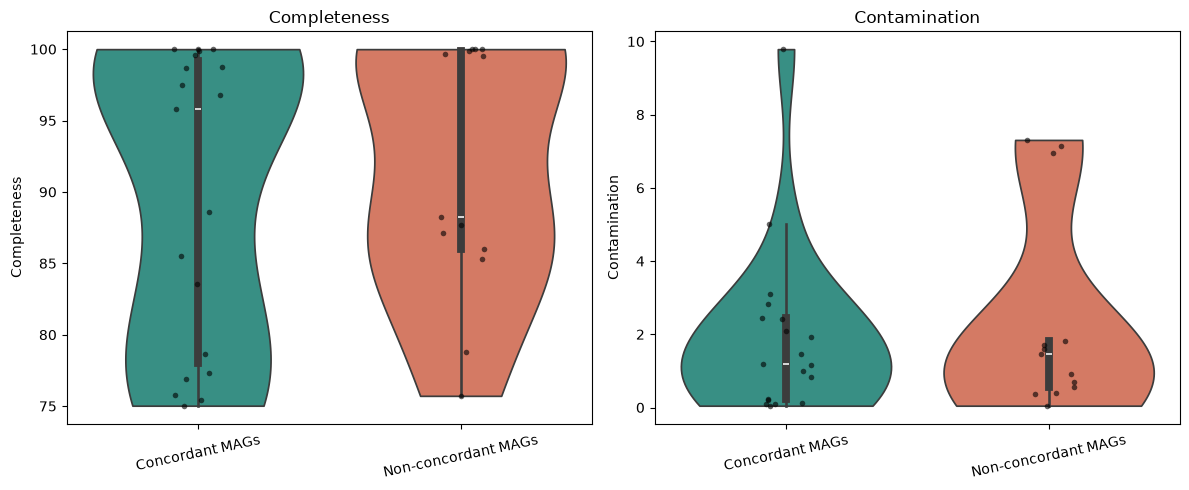

In [53]:
metrics = ["Completeness", "Contamination"]
group_order = ["Concordant MAGs", "Non-concordant MAGs"]

plot_frames = []
for group_name, frame in [
    ("Concordant MAGs", concordant_mags),
    ("Non-concordant MAGs", non_concordant_mags),
]:
    subset = frame[metrics].copy()
    for metric in metrics:
        subset[metric] = pd.to_numeric(subset[metric], errors="coerce")
    subset["Group"] = group_name
    plot_frames.append(subset)

plot_df = pd.concat(plot_frames, ignore_index=True)

palette = {
    "Concordant MAGs": "#2a9d8f",
    "Non-concordant MAGs": "#e76f51",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, metrics):
    sns.violinplot(
        data=plot_df,
        x="Group",
        y=metric,
        hue="Group",
        order=group_order,
        hue_order=group_order,
        palette=palette,
        cut=0,
        inner="box",
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="Group",
        y=metric,
        order=group_order,
        color="black",
        alpha=0.6,
        size=4,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=12)

plt.tight_layout()
plt.show()